<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


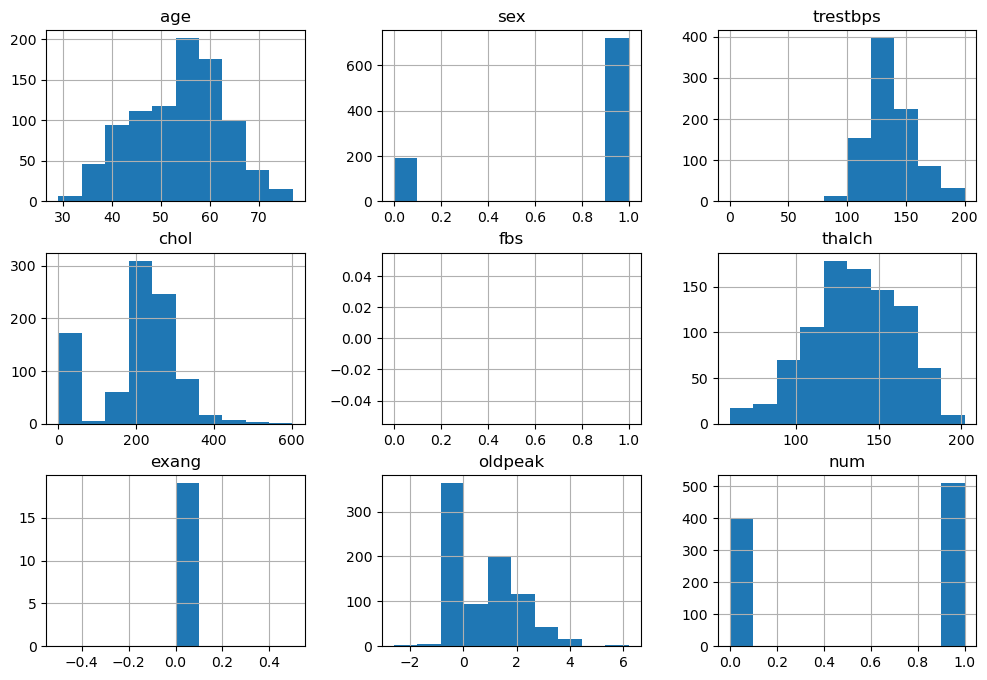

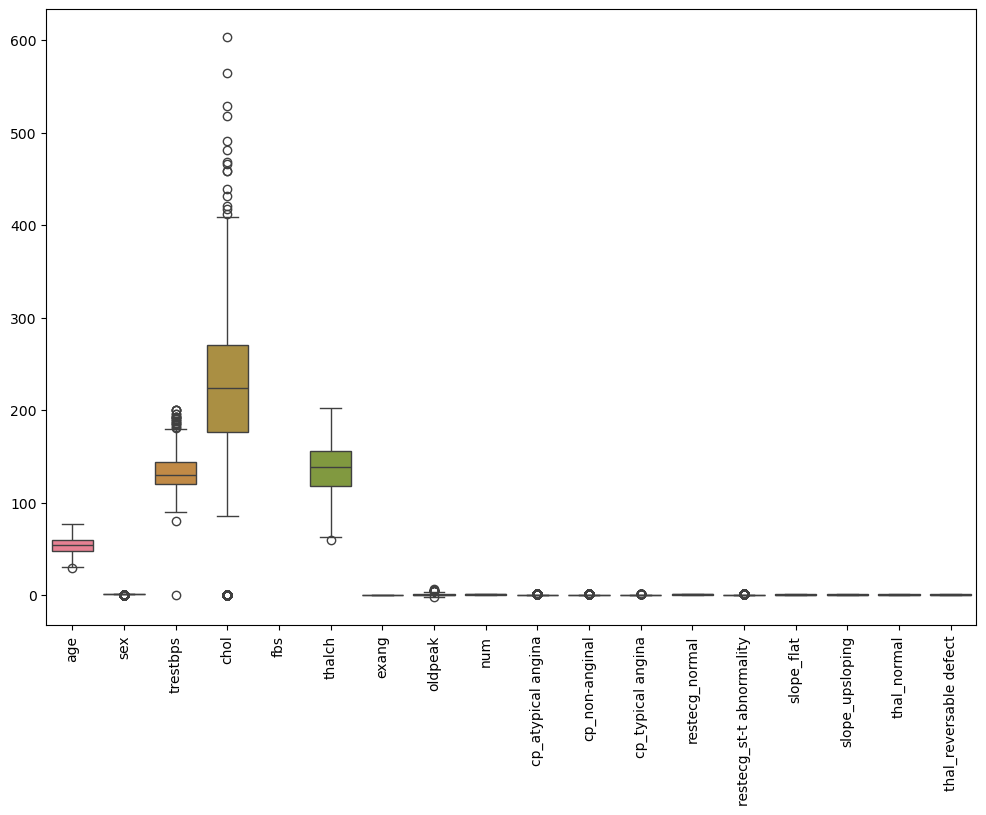

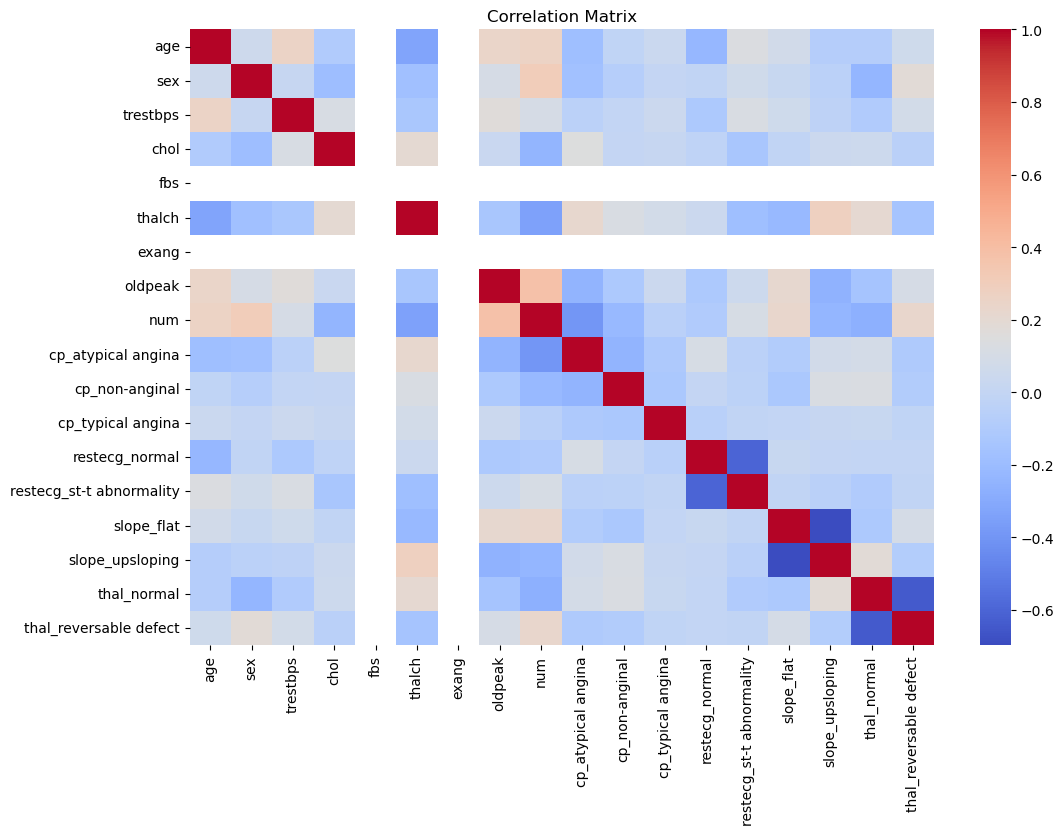

Accuracy: 0.7857142857142857

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.79      0.78        89
           1       0.79      0.78      0.79        93

    accuracy                           0.79       182
   macro avg       0.79      0.79      0.79       182
weighted avg       0.79      0.79      0.79       182



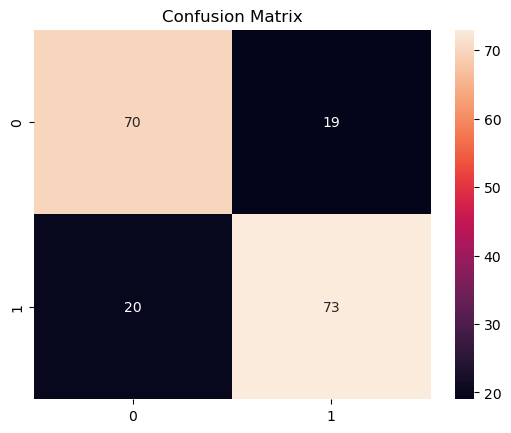

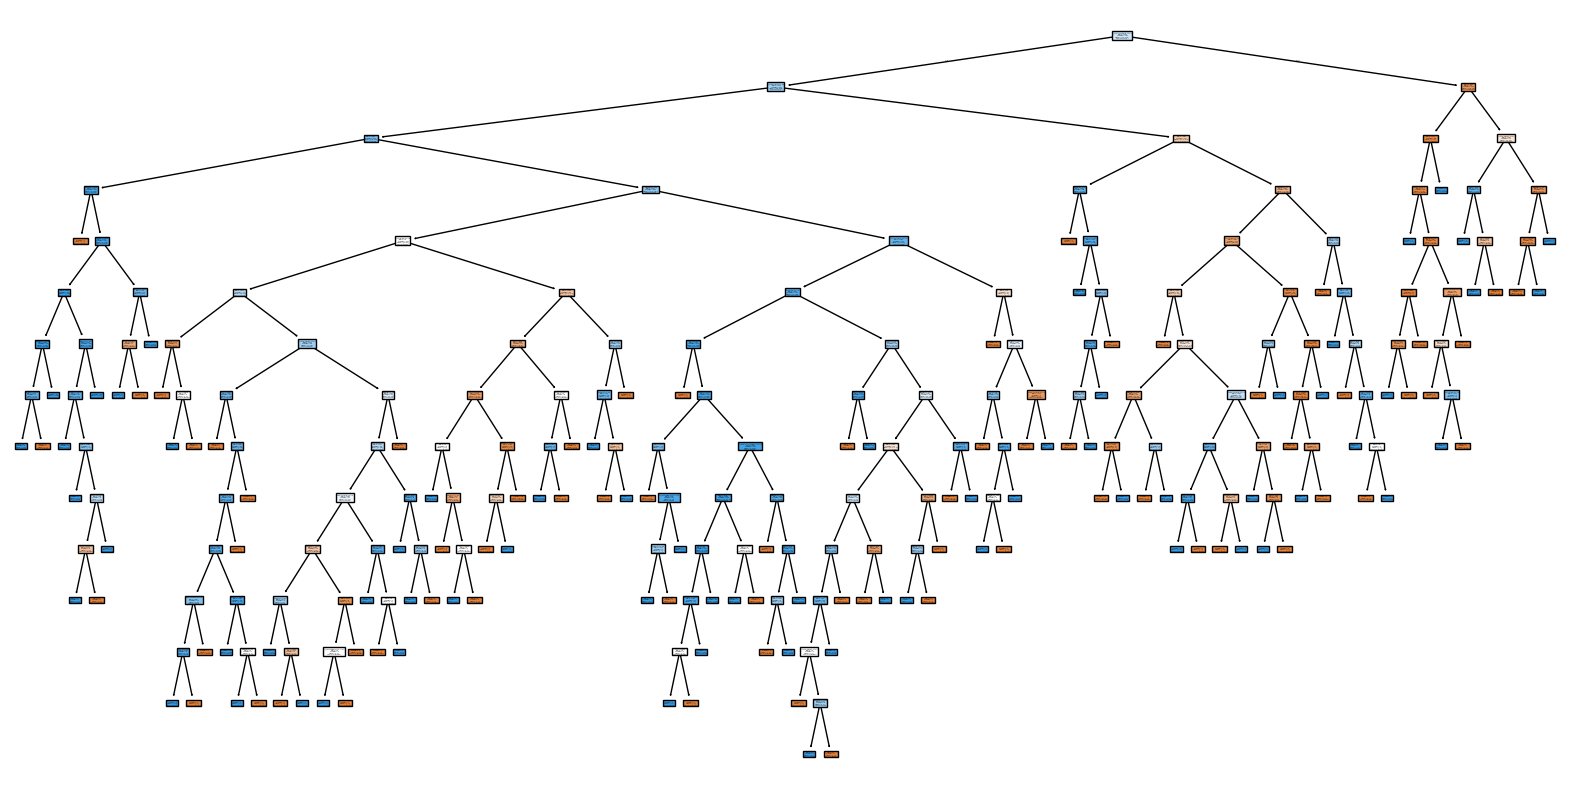

Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 2}


In [1]:
import numpy as np
import pandas as pd

file_path=r"C:\Users\NIKHIL\Downloads\data science assignment\data science assignment\heart_disease.xlsx"
df=pd.read_excel(file_path, sheet_name="Heart_disease")

df.info()

df.describe()

df.head()

df.isnull().sum()

df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
df['fbs'] = df['fbs'].map({'TRUE':1, 'FALSE':0})
df['exang'] = df['exang'].map({'TRUE':1, 'FALSE':0})
df['sex'] = df['sex'].map({'Male':1, 'Female':0})

df = pd.get_dummies(df, columns=['cp','restecg','slope','thal'], drop_first=True)

import matplotlib.pyplot as plt
import seaborn as sns

df.hist(figsize=(12,8))
plt.show()

plt.figure(figsize=(12,8))
sns.boxplot(df)
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

from sklearn.model_selection import train_test_split
X = df.drop('num', axis=1)
y = df['num']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
    )

from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(model, feature_names=X.columns, class_names=['No Disease','Disease'], filled=True)
plt.show()

from sklearn.model_selection import GridSearchCV
params = {
    'max_depth':[3,5,7,9],
    'min_samples_split':[2,5,10],
    'criterion':['gini','entropy']
}
grid = GridSearchCV(DecisionTreeClassifier(), params, cv=5)
grid.fit(X_train,y_train)
print("Best Parameters:",grid.best_params_)




# Interview Questions

1. What is a Decision Tree?
A Decision Tree is a supervised machine learning algorithm used for classification and regression tasks. It splits data into branches based on feature conditions.

2. What is Gini Index?
Gini Index is a metric used to measure impurity in a Decision Tree. Lower Gini value indicates better purity.

3. What is Entropy in Decision Trees?
Entropy measures randomness or impurity in the dataset. Decision Trees use entropy to select the best split.

4. What is Overfitting in Decision Trees?
Overfitting occurs when the model learns training data too well and performs poorly on unseen data.

5. What is Pruning in Decision Trees?
Pruning is the process of removing unnecessary branches from the tree to reduce overfitting and improve generalization.